In [1]:
import gymnasium as gym

In [2]:
# the training environment
env = gym.make("CartPole-v1", render_mode="human")
# 'render_mode' specifies how the environment should be visualized
# 'human' -> a visual window
# 'rgb_array' -> image arrays
# None -> run without visuals

In [3]:
# reset env
observation, info = env.reset()

In [4]:
print(f"starting observation: {observation}")
# cart position, cart velocity, pole_angle, pole angular velocity

starting observation: [ 0.02242056  0.0437199   0.03010109 -0.03362727]


In [5]:
episode_over = False
total_reward = 0

In [6]:
while not episode_over:
  # choose an action
  action = env.action_space.sample() # random for now
  # take action
  observation, reward, terminated, truncated, info = env.step(action)

  # reward +1 for each step the pole stays upright
  # terminated: True if pole falls too far (agent failed)
  # truncated: True if we hit the time limit (500 steps)

  total_reward += reward
  episode_over = terminated or truncated

print(f"Episode finished! Total Reward: {total_reward}")
env.close()

Episode finished! Total Reward: 25.0


In [7]:
# using spaces
import gymnasium as gym
env = gym.make("CartPole-v1")
print(f"Action Space: {env.action_space}")
print(f"Sample Action: {env.action_space.sample()}")

# box observation space(continuous values)
print(f"Observation space: {env.observation_space}")
print(f"sample observation: {env.observation_space.sample()}")

Action Space: Discrete(2)
Sample Action: 0
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
sample observation: [ 4.6551757   0.20100309 -0.03715147 -0.4775322 ]


In [8]:
## modifying an environment
!pip install gymnasium[box2d] -q

import gymnasium as gym
from gymnasium.wrappers import FlattenObservation

env = gym.make("CarRacing-v3")
print(env.observation_space.shape)

# wrap to flatten observation to a 1d array
wrapped_env= FlattenObservation(env)
print(wrapped_env.observation_space.shape)

# this allows you use algorithms that expect 1D input

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 71.0 MB/s eta 0:00:00
(96, 96, 3)
(27648,)


### common wrappers
- TimeLimit: gives a truncated signal if a maximum number of timesteps has been exceeded

- ClipAction: Clips any action passed to step, ensures it is within the valid action space

- RescaleAction: Rescales actions to a dfieerenet range (useful for algorithms that output actions in [-1, 1] but environment expects [0, 10])

- TimeAwareObservation: Adds information about the current timestep to the observation

other wrappers -> https://gymnasium.farama.org/api/wrappers/

In [9]:
# to access a wrapped environment's original environment: use unwrapped
print(wrapped_env)
print(wrapped_env.unwrapped)

<FlattenObservation<TimeLimit<OrderEnforcing<PassiveEnvChecker<CarRacing<CarRacing-v3>>>>>>
<CarRacing<CarRacing-v3>>


## Training an Agent

In [17]:
from collections import defaultdict
import gymnasium as gym
import numpy as np

class BlackjackAgent:
  def __init__(self, env: gym.Env, learning_rate: float, init_epsilon: float, epsilon_decay: float, final_epsilon: float, discount_factor: float=0.95):
    """init a Q-learning agent.
    Args:
      env: the training environment
      learning_rate: how quick you update q vales
      init_epsilon: starting exploration rate (usually 1.0)
      epsilon_decay: how much to reduce epsilon per episode
      final_epsilon: lowest value of epsilon (usually 0.1)
      discount_factor: how much to value future rewards (0-1)
    """

    self.env = env
    # q table: maps (state, action) to expected reward
    # defaultdict creates entries with zeros for new states
    self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
    self.lr = learning_rate
    self.discount_factor = discount_factor


    # exploration params
    self.epsilon = init_epsilon
    self.epsilon_decay = epsilon_decay
    self.final_epsilon = final_epsilon

    # track learning progress
    self.training_error = []

  def get_action(self, obs: tuple[int, int, bool]) -> int:
    """Choose an action using epsioon-greedy strategy.

    Returns:
      action: 0 (stand) or 1 (hit)
    """
    # with e-greedy probability: explore(random action)
    if np.random.random() < self.epsilon:
      return self.env.action_space.sample() # random action, same as exploring?

    # with probability (1 - epsilon): exploit
    else:
      return int(np.argmax(self.q_values[obs]))

  def update(self, obs: tuple[int, int, bool], action:int, reward:float, terminated: bool, next_obs: tuple[int, int, bool]):
    """Update Q-values based on experience.
    This is the heart of Q-learning. learn from state, action, reward, next_state)
    """

    # what is the best we could do fromthe next state?
    # (zero if episode terminated - no future rewards possible)
    future_q_value = (not terminated) * np.max(self.q_values[next_obs])

    # what should the q value be? (bellman equation)
    target = reward + self.discount_factor * future_q_value

    # how wrong was our current estimate
    temporal_difference = target - self.q_values[obs][action]

    # update out estimate in the direction of the error
    # learning rate controls how big steps we take
    self.q_values[obs][action] = (
        self.q_values[obs][action] + self.lr * temporal_difference
    )

    # track learning
    self.training_error.append(temporal_difference)

  def decay_epsilon(self):
    """Reduce exploration rate after each episode"""
    self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)



In [18]:
## trainig the agent

learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

# create environment and agent
env = gym.make("Blackjack-v1", sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    init_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon
)


### trainig loop

In [19]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
  # start a new hand
  obs, info = env.reset()
  done=False

  # play a complete hand
  while not done:
    # Agent choosese action (initially random)
    action = agent.get_action(obs)

    # take action and observe results
    next_obs, reward, terminated, truncated, info = env.step(action)

    # learn from this experience
    agent.update(obs, action, reward, terminated, next_obs)

    # move ot the next state
    done = terminated or truncated
    obs = next_obs

  # reduce exploration rate
  agent.decay_epsilon()

100%|██████████| 100000/100000 [00:18<00:00, 5315.95it/s]


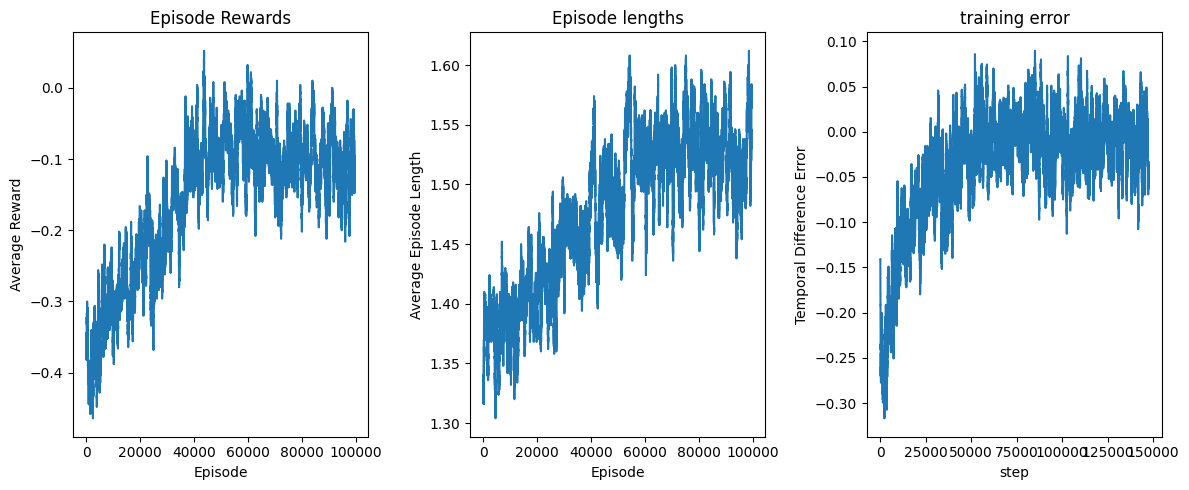

In [24]:
## analyze training results
import matplotlib.pyplot as plt

def get_moving_average(arr, window, convolution_mode):
  # Convert the deque to a numpy array directly
  return np.convolve(np.array(arr), np.ones(window), mode=convolution_mode) / window

rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12,5))

axs[0].set_title("Episode Rewards")
reward_moving_average = get_moving_average(
    env.return_queue,
    rolling_length,
    "valid"
)

axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# episode lengths (num actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_average(
    env.length_queue,
    rolling_length,
    "valid"
)

axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# training error
axs[2].set_title("training error")
training_error_moving_average = get_moving_average(
    agent.training_error,
    rolling_length,
    "same"
)

axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("step")

plt.tight_layout()
plt.show()

# testing blackjack agent

In [26]:
def test_agent(agent, env, num_episodes=1000):
  """Test agent's performance without learning or exploration"""
  total_rewards = []

  # disable exploration for testing
  old_epsilon = agent.epsilon
  agent.epsilon = 0.0 # pure exploitation

  for _ in range(num_episodes):
    obs, info = env.reset()
    episode_reward = 0
    done = False

    while not done:
      action = agent.get_action(obs)
      obs, reward, terminated, truncated, info = env.step(action)
      episode_reward += reward
      done = terminated or truncated

    total_rewards.append(episode_reward)

  # restore original epsilon
  agent.epsilon = old_epsilon

  win_rate = np.mean(np.array(total_rewards) > 0)
  average_reward = np.mean(total_rewards)

  print(f"Test results over: {num_episodes} episodes")
  print(f"Win rate: {win_rate:.1%}")
  print(f"Aerage reward: {average_reward:.3f}")
  print(f"Standard Deviation: {np.std(total_rewards):.3f}")

test_agent(agent, env)

Test results over: 1000 episodes
Win rate: 42.6%
Aerage reward: -0.064
Standard Deviation: 0.955
